## 2. 多层感知机基础

### 2.1 练习题

设输入向量 $x \in \mathbb{R}^{d}$，隐藏层宽度为 $m$，输出类别数为 $k$。单隐藏层 MLP 为

$$
h = W_1 x + b_1,\qquad o = W_2 h + b_2.
$$

为了使矩阵乘法维度匹配：

$$
W_1 \in \mathbb{R}^{m \times d},\quad b_1 \in \mathbb{R}^{m},\quad
W_2 \in \mathbb{R}^{k \times m},\quad b_2 \in \mathbb{R}^{k}.
$$

若使用 mini-batch，$X \in \mathbb{R}^{n \times d}$，通常写成

$$
H = X W_1^\top + b_1,\qquad O = H W_2^\top + b_2,
$$

此时 $H \in \mathbb{R}^{n \times m}$，$O \in \mathbb{R}^{n \times k}$。

Sigmoid 与 tanh 的表达式和导数：

$$
\sigma(x)=\frac{1}{1+e^{-x}},\qquad \sigma'(x)=\sigma(x)(1-\sigma(x)).
$$

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}},\qquad
\tanh'(x)=1-\tanh^2(x).
$$


### 2.2 编程题：低阶张量实现单隐藏层 MLP

要求：初始化 $W_1,b_1,W_2,b_2$；实现 ReLU 前向传播；实现带 Softmax 的交叉熵；使用 mini-batch SGD 更新参数。


In [1]:
import math
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


def load_image_classification_data(max_train=2048, max_val=512):
    # Prefer local Fashion-MNIST; fall back to sklearn digits when offline.
    try:
        from torchvision import datasets, transforms

        transform = transforms.Compose([transforms.ToTensor()])
        train_ds = datasets.FashionMNIST(
            root="./data", train=True, download=False, transform=transform
        )
        test_ds = datasets.FashionMNIST(
            root="./data", train=False, download=False, transform=transform
        )
        n_train = min(max_train, len(train_ds))
        n_val = min(max_val, len(test_ds))
        X_train = torch.stack([train_ds[i][0].reshape(-1) for i in range(n_train)])
        y_train = torch.tensor([train_ds[i][1] for i in range(n_train)])
        X_val = torch.stack([test_ds[i][0].reshape(-1) for i in range(n_val)])
        y_val = torch.tensor([test_ds[i][1] for i in range(n_val)])
        source = "Fashion-MNIST (local cache)"
    except Exception as exc:
        digits = load_digits()
        X = digits.images.astype(np.float32) / 16.0
        X = np.kron(X, np.ones((3, 3), dtype=np.float32))
        X = np.pad(X, ((0, 0), (2, 2), (2, 2)), mode="constant")
        X = X.reshape(len(X), -1)
        y = digits.target.astype(np.int64)
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
        X_train = torch.tensor(X_train[:max_train])
        y_train = torch.tensor(y_train[:max_train])
        X_val = torch.tensor(X_val[:max_val])
        y_val = torch.tensor(y_val[:max_val])
        source = f"sklearn digits fallback ({type(exc).__name__}: Fashion-MNIST cache unavailable)"

    return X_train.float(), y_train.long(), X_val.float(), y_val.long(), source


X_train, y_train, X_val, y_val, data_source = load_image_classification_data()
num_inputs = X_train.shape[1]
num_outputs = int(torch.max(torch.cat([y_train, y_val])).item()) + 1

print("data source:", data_source)
print("train:", tuple(X_train.shape), "val:", tuple(X_val.shape), "classes:", num_outputs)


data source: sklearn digits fallback (RuntimeError: Fashion-MNIST cache unavailable)
train: (1347, 784) val: (450, 784) classes: 10


In [2]:
def init_mlp_params(num_inputs, num_hidden, num_outputs, std=0.01):
    W1 = torch.randn(num_hidden, num_inputs) * std
    b1 = torch.zeros(num_hidden)
    W2 = torch.randn(num_outputs, num_hidden) * std
    b2 = torch.zeros(num_outputs)
    for p in (W1, b1, W2, b2):
        p.requires_grad_(True)
    return [W1, b1, W2, b2]


def relu(X):
    return torch.maximum(X, torch.zeros_like(X))


def softmax(logits):
    shifted = logits - logits.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(shifted)
    return exp_logits / exp_logits.sum(dim=1, keepdim=True)


def cross_entropy_from_probs(probs, y):
    return -torch.log(probs[torch.arange(len(y)), y] + 1e-12).mean()


def net(X, params):
    W1, b1, W2, b2 = params
    H = relu(torch.matmul(X, W1.T) + b1)
    return torch.matmul(H, W2.T) + b2


def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = torch.randperm(len(X)) if shuffle else torch.arange(len(X))
    for start in range(0, len(X), batch_size):
        batch_idx = indices[start : start + batch_size]
        yield X[batch_idx], y[batch_idx]


def train_manual_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    num_hidden=128,
    lr=0.5,
    batch_size=128,
    epochs=8,
):
    params = init_mlp_params(X_train.shape[1], num_hidden, num_outputs)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size):
            probs = softmax(net(Xb, params))
            loss = cross_entropy_from_probs(probs, yb)
            loss.backward()

            with torch.no_grad():
                for p in params:
                    p -= lr * p.grad
                    p.grad.zero_()

        with torch.no_grad():
            train_probs = softmax(net(X_train, params))
            val_logits = net(X_val, params)
            val_probs = softmax(val_logits)
            history["train_loss"].append(cross_entropy_from_probs(train_probs, y_train).item())
            history["val_loss"].append(cross_entropy_from_probs(val_probs, y_val).item())
            history["val_acc"].append(accuracy(val_logits, y_val))
        print(
            f"epoch {epoch + 1:02d}: "
            f"train loss={history['train_loss'][-1]:.4f}, "
            f"val loss={history['val_loss'][-1]:.4f}, "
            f"val acc={history['val_acc'][-1]:.3f}"
        )

    return params, history


manual_params, manual_history = train_manual_mlp(X_train, y_train, X_val, y_val)


epoch 01: train loss=1.6282, val loss=1.6427, val acc=0.327


epoch 02: train loss=1.4601, val loss=1.4885, val acc=0.473
epoch 03: train loss=0.7219, val loss=0.7523, val acc=0.724


epoch 04: train loss=0.5890, val loss=0.5869, val acc=0.851
epoch 05: train loss=0.3731, val loss=0.3753, val acc=0.893
epoch 06: train loss=0.3391, val loss=0.4086, val acc=0.844
epoch 07: train loss=0.1792, val loss=0.2221, val acc=0.920
epoch 08: train loss=0.1801, val loss=0.1879, val acc=0.947


---

## 3. 泛化、正则化与 Dropout

### 3.1 练习题

训练误差是模型在训练集上的平均损失或错误率；验证误差是在独立验证集上评估得到的误差；泛化误差是模型在真实数据分布上新样本的期望误差，实际中不可直接完全观测，通常用验证集或测试集估计。

当模型容量过大、训练时间过长或正则化不足时，训练误差会持续下降，但验证误差可能先下降后上升，这就是过拟合现象。理想模型应在训练误差和验证误差之间取得平衡。

K 折交叉验证步骤：

1. 将数据集随机划分为大小相近的 $K$ 份。
2. 每次取其中 1 份作为验证集，其余 $K-1$ 份作为训练集。
3. 重复 $K$ 次，使每一份都恰好做一次验证集。
4. 将 $K$ 次验证误差取平均，作为模型或超参数组合的性能估计。


### 3.2 编程题：L2 正则化与 Dropout

要求：SGD 中加入权重衰减，权重先乘以 $(1-\eta\lambda)$；实现 `dropout_layer(X, dropout)`，训练时随机置零并缩放，测试时关闭；比较无正则、L2、Dropout 三种验证损失曲线。


baseline: final val loss=0.3120, val acc=0.920


L2: final val loss=0.1708, val acc=0.938


dropout: final val loss=0.3651, val acc=0.880


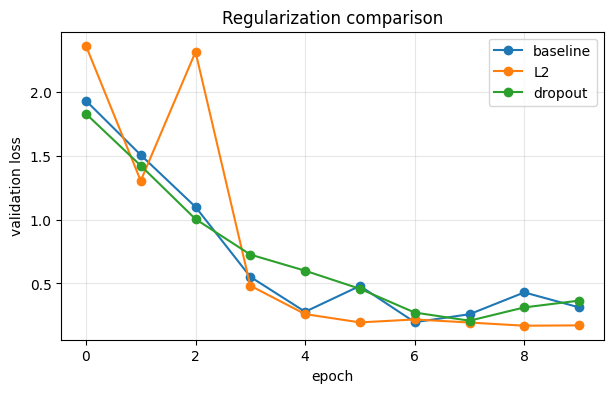

In [3]:
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)


def net_with_dropout(X, params, dropout=0.0, is_training=True):
    W1, b1, W2, b2 = params
    H = relu(torch.matmul(X, W1.T) + b1)
    H = dropout_layer(H, dropout, is_training=is_training)
    return torch.matmul(H, W2.T) + b2


def train_regularized_mlp(name, weight_decay=0.0, dropout=0.0, epochs=10, lr=0.5):
    params = init_mlp_params(X_train.shape[1], 128, num_outputs)
    history = {"val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size=128):
            probs = softmax(net_with_dropout(Xb, params, dropout, is_training=True))
            loss = cross_entropy_from_probs(probs, yb)
            loss.backward()

            with torch.no_grad():
                for i, p in enumerate(params):
                    is_weight = i in (0, 2)
                    if is_weight and weight_decay > 0:
                        p *= 1 - lr * weight_decay
                    p -= lr * p.grad
                    p.grad.zero_()

        with torch.no_grad():
            val_logits = net_with_dropout(X_val, params, dropout, is_training=False)
            val_probs = softmax(val_logits)
            history["val_loss"].append(cross_entropy_from_probs(val_probs, y_val).item())
            history["val_acc"].append(accuracy(val_logits, y_val))

    print(f"{name}: final val loss={history['val_loss'][-1]:.4f}, val acc={history['val_acc'][-1]:.3f}")
    return history


histories = {
    "baseline": train_regularized_mlp("baseline", weight_decay=0.0, dropout=0.0),
    "L2": train_regularized_mlp("L2", weight_decay=1e-3, dropout=0.0),
    "dropout": train_regularized_mlp("dropout", weight_decay=0.0, dropout=0.5),
}

plt.figure(figsize=(7, 4))
for name, hist in histories.items():
    plt.plot(hist["val_loss"], marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("Regularization comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---

## 4. 深层网络中的梯度

### 4.1 练习题

深层网络反向传播时，某一层隐藏状态的梯度可写成多个雅可比矩阵连乘：

$$
\frac{\partial h_d}{\partial h_t}
= \prod_{i=t}^{d-1}\frac{\partial h_{i+1}}{\partial h_i}.
$$

如果每一项的谱范数多数小于 1，连乘后梯度会指数级变小，前面层几乎得不到有效更新，这就是梯度消失；如果多数大于 1，则可能出现梯度爆炸。

Sigmoid 的导数最大只有 $0.25$，并且在饱和区接近 $0$，所以深层 Sigmoid 网络很容易梯度消失。ReLU 在正半轴导数为 $1$，能减少饱和导致的梯度消失；但 ReLU 仍需要合适初始化，否则过大初值会造成激活和梯度爆炸，甚至出现 NaN。


### 4.2 编程题：20 层网络的梯度范数实验


Sigmoid + Normal(std=1): loss=1.795e+02, finite=True, first layer grad=1.463e+03, median grad=2.517e+02, last layer grad=2.766e+02
ReLU + Normal(std=10): loss=nan, finite=False, first layer grad=nan, median grad=nan, last layer grad=nan
ReLU + Xavier: loss=8.227e-01, finite=True, first layer grad=1.995e-03, median grad=2.516e-03, last layer grad=2.227e-03


LeakyReLU + Xavier: loss=8.225e-01, finite=True, first layer grad=1.919e-03, median grad=2.458e-03, last layer grad=2.096e-03


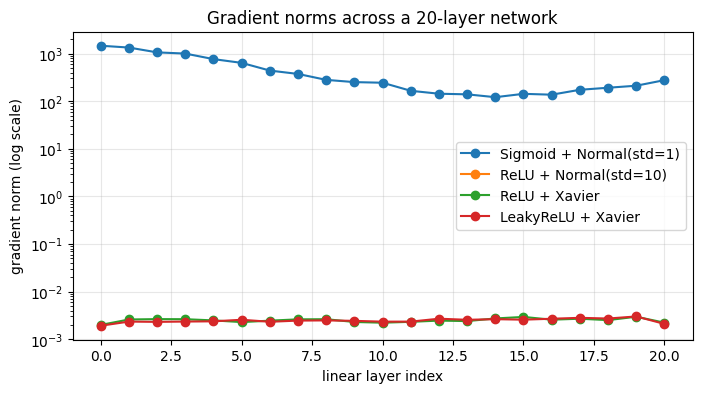

In [4]:
import torch.nn as nn


def make_deep_net(input_dim=64, hidden=256, depth=20, activation="sigmoid", init="normal1"):
    layers = []
    act_cls = {"sigmoid": nn.Sigmoid, "relu": nn.ReLU, "leaky_relu": nn.LeakyReLU}[activation]
    for i in range(depth):
        in_dim = input_dim if i == 0 else hidden
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(act_cls())
    layers.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*layers)

    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init == "normal1":
                nn.init.normal_(m.weight, mean=0, std=1)
            elif init == "normal10":
                nn.init.normal_(m.weight, mean=0, std=10)
            elif init == "xavier":
                nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    return model


def gradient_norms(model, X, y):
    model.zero_grad(set_to_none=True)
    pred = model(X)
    loss = ((pred - y) ** 2).mean()
    loss.backward()
    norms = []
    finite = True
    for layer_idx, layer in enumerate(m for m in model if isinstance(m, nn.Linear)):
        norm = layer.weight.grad.norm().item()
        norms.append(norm)
        finite = finite and math.isfinite(norm)
    return loss.item(), norms, finite


X_deep = torch.randn(128, 64)
y_deep = torch.randn(128, 1)

settings = [
    ("Sigmoid + Normal(std=1)", "sigmoid", "normal1"),
    ("ReLU + Normal(std=10)", "relu", "normal10"),
    ("ReLU + Xavier", "relu", "xavier"),
    ("LeakyReLU + Xavier", "leaky_relu", "xavier"),
]

grad_results = {}
for name, activation, init in settings:
    model = make_deep_net(activation=activation, init=init)
    loss, norms, finite = gradient_norms(model, X_deep, y_deep)
    grad_results[name] = norms
    print(
        f"{name}: loss={loss:.3e}, finite={finite}, "
        f"first layer grad={norms[0]:.3e}, median grad={np.median(norms):.3e}, "
        f"last layer grad={norms[-1]:.3e}"
    )

plt.figure(figsize=(8, 4))
for name, norms in grad_results.items():
    clipped = np.clip(norms, 1e-12, 1e12)
    plt.plot(clipped, marker="o", label=name)
plt.yscale("log")
plt.xlabel("linear layer index")
plt.ylabel("gradient norm (log scale)")
plt.title("Gradient norms across a 20-layer network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---

## 5. 分布偏移与协变量偏移

### 5.1 练习题

协变量偏移（Covariate Shift）指训练分布与测试分布的输入边缘分布不同：

$$
p(x)\ne q(x),
$$

但条件标注机制不变：

$$
p(y\mid x)=q(y\mid x).
$$

例如训练样本多来自低亮度图像，测试样本多来自高亮度图像，但同一图像内容对应的类别规则不变。

标签偏移（Label Shift）指类别先验不同：

$$
p(y)\ne q(y),
$$

但每个类别内部的特征分布不变：

$$
p(x\mid y)=q(x\mid y).
$$

两者区别在于：协变量偏移改变的是输入 $x$ 的分布，标签偏移改变的是类别比例；联系在于二者都属于训练分布和测试分布不一致的问题，会导致经验风险不能直接代表测试风险。


### 5.2 编程题：重要性加权修正协变量偏移


plain Ridge:    y = 1.959x + -0.005, Q MSE=0.2635
weighted Ridge: y = 2.043x + -0.023, Q MSE=0.2584
weight range: min=0.000, median=0.008, max=30.000


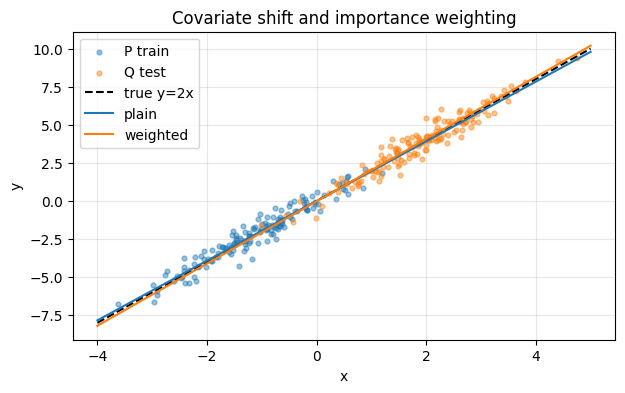

In [5]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error

np.random.seed(42)

n_train = 1000
n_test = 500

X_p = np.random.normal(loc=-1.0, scale=1.0, size=(n_train, 1))
y_p = 2 * X_p[:, 0] + np.random.normal(0, 0.5, size=n_train)

X_q = np.random.normal(loc=2.0, scale=1.0, size=(n_test, 1))
y_q = 2 * X_q[:, 0] + np.random.normal(0, 0.5, size=n_test)

plain_model = Ridge(alpha=10.0)
plain_model.fit(X_p, y_p)
plain_mse = mean_squared_error(y_q, plain_model.predict(X_q))

X_domain = np.vstack([X_p, X_q])
y_domain = np.r_[np.zeros(n_train), np.ones(n_test)]

domain_clf = LogisticRegression()
domain_clf.fit(X_domain, y_domain)

proba = domain_clf.predict_proba(X_p)
p_train_given_x = proba[:, 0]
p_test_given_x = proba[:, 1]

weights = p_test_given_x / np.maximum(p_train_given_x, 1e-6)
weights = weights / weights.mean()
weights = np.clip(weights, 0, 30)

weighted_model = Ridge(alpha=10.0)
weighted_model.fit(X_p, y_p, sample_weight=weights)
weighted_mse = mean_squared_error(y_q, weighted_model.predict(X_q))

print(f"plain Ridge:    y = {plain_model.coef_[0]:.3f}x + {plain_model.intercept_:.3f}, Q MSE={plain_mse:.4f}")
print(f"weighted Ridge: y = {weighted_model.coef_[0]:.3f}x + {weighted_model.intercept_:.3f}, Q MSE={weighted_mse:.4f}")
print(f"weight range: min={weights.min():.3f}, median={np.median(weights):.3f}, max={weights.max():.3f}")

x_grid = np.linspace(-4, 5, 300).reshape(-1, 1)
plt.figure(figsize=(7, 4))
plt.scatter(X_p[:150], y_p[:150], s=12, alpha=0.45, label="P train")
plt.scatter(X_q[:150], y_q[:150], s=12, alpha=0.45, label="Q test")
plt.plot(x_grid, 2 * x_grid[:, 0], "k--", label="true y=2x")
plt.plot(x_grid, plain_model.predict(x_grid), label="plain")
plt.plot(x_grid, weighted_model.predict(x_grid), label="weighted")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Covariate shift and importance weighting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
